# Image Tampering Detection
### Using ELA (Error Level Analysis) and Metadata Analysis

This notebook detects image tampering using two approaches:
1. **ELA (Error Level Analysis)**: Analyzes compression artifacts using a DenseNet121 model
2. **Weather Metadata Validation**: Validates weather conditions using EXIF metadata and historical weather data

**Final Output**: A tampering confidence score (0-100%) where higher scores indicate higher likelihood of tampering.

## 1. Import Required Libraries

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageChops, ImageEnhance
from exif import Image as ExifImage
from urllib.request import urlopen
import json
from geopy.geocoders import Nominatim
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Define Helper Functions

### 2.1 ELA Helper Functions

In [39]:
def convert_to_ela_image(path, quality=90):
    """
    Performs Error Level Analysis on an image.
    
    Args:
        path: Path to the image file
        quality: JPEG compression quality (default: 90)
    
    Returns:
        PIL Image: ELA processed image
    """
    temp_filename = 'temp_file_name.jpg'
    
    # Open and save with specified quality
    image = Image.open(path).convert('RGB')
    image.save(temp_filename, 'JPEG', quality=quality)
    temp_image = Image.open(temp_filename)
    
    # Calculate difference
    ela_image = ImageChops.difference(image, temp_image)
    
    # Scale the differences
    extrema = ela_image.getextrema()
    max_diff = sum([ex[1] for ex in extrema]) / 3
    if max_diff == 0:
        max_diff = 1
    
    scale = 255.0 / max_diff
    ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)
    
    # Clean up temp file
    if os.path.exists(temp_filename):
        os.remove(temp_filename)
    
    return ela_image


def prepare_image_for_ela(image_path):
    """
    Prepares image for ELA model prediction.
    
    Args:
        image_path: Path to the image
    
    Returns:
        tuple: (prepared numpy array, ELA image)
    """
    ela_img = convert_to_ela_image(image_path, 90)
    img = np.array(ela_img.resize((128, 128))).flatten() / 255.0
    img = img.reshape(128, 128, 3)
    return np.expand_dims(img, axis=0), ela_img


def prepare_image_for_weather(image_path):
    """
    Prepares image for weather model prediction.
    
    Args:
        image_path: Path to the image
    
    Returns:
        numpy array: Prepared image array
    """
    img = np.array(Image.open(image_path).convert('RGB').resize((128, 128))) / 255.0
    img = img.reshape(128, 128, 3)
    return np.expand_dims(img, axis=0)


print("ELA helper functions defined successfully!")

ELA helper functions defined successfully!


### 2.2 Metadata Analysis Helper Functions

In [40]:
# Weather code mapping
weatherDict = {
    0: 'Sunny',
    1: 'Clear or partly cloudy',
    2: 'Clear or partly cloudy',
    3: 'Slight Rain',
    45: 'Fog',
    48: 'Fog',
    51: 'Slight Raining',
    53: 'Slight Raining',
    55: 'Slight Raining',
    56: 'Slight Raining',
    57: 'Slight Raining',
    61: 'Raining',
    63: 'Raining',
    65: 'Raining',
    66: 'Raining',
    67: 'Raining',
    71: 'Snow',
    73: 'Snow',
    75: 'Snow',
    77: 'Snow',
    80: 'Raining',
    81: 'Raining',
    82: 'Raining',
    85: 'Snow',
    86: 'Snow',
    95: 'Lightning',
    96: 'Lightning',
    99: 'Lightning'
}


def decimal_coords(coords, ref):
    """
    Converts GPS coordinates to decimal format.
    
    Args:
        coords: Tuple of (degrees, minutes, seconds)
        ref: Reference direction (N, S, E, W)
    
    Returns:
        float: Decimal coordinate
    """
    decimal_degrees = coords[0] + coords[1] / 60 + coords[2] / 3600
    if ref == "S" or ref == 'W':
        decimal_degrees = -decimal_degrees
    return decimal_degrees


def extract_image_metadata(image_path):
    """
    Extracts GPS and datetime metadata from image.
    
    Args:
        image_path: Path to the image
    
    Returns:
        tuple: (datetime, latitude, longitude, has_metadata)
    """
    try:
        with open(image_path, 'rb') as src:
            img = ExifImage(src)
        
        if not img.has_exif:
            return None, None, None, False
        
        # Extract GPS coordinates
        try:
            latitude = decimal_coords(img.gps_latitude, img.gps_latitude_ref)
            longitude = decimal_coords(img.gps_longitude, img.gps_longitude_ref)
        except AttributeError:
            return None, None, None, False
        
        # Extract datetime
        try:
            date_time = img.datetime_original
        except AttributeError:
            try:
                date_time = img.gps_datestamp + " 12:00:00"
            except:
                return None, None, None, False
        
        return date_time, latitude, longitude, True
    
    except Exception as e:
        print(f"Error extracting metadata: {e}")
        return None, None, None, False


def get_historical_weather(date_time, lat, lon):
    """
    Fetches historical weather data from API.
    
    Args:
        date_time: DateTime string from image metadata
        lat: Latitude
        lon: Longitude
    
    Returns:
        tuple: (location_name, date, weather_condition)
    """
    try:
        # Parse date and time
        date = date_time[:10].replace(':', '-')
        time = date_time[11:]
        hour = int(time[:2])
        
        # Get location name
        geoLoc = Nominatim(user_agent="ImageTamperingDetector")
        locname = geoLoc.reverse(f"{lat},{lon}")
        
        # Fetch weather data
        base_url = 'https://archive-api.open-meteo.com/v1/era5?'
        url = f"{base_url}latitude={lat}&longitude={lon}&start_date={date}&end_date={date}&hourly=weathercode&timezone=Asia%2FBangkok"
        
        response = urlopen(url)
        data_json = json.loads(response.read())
        
        weather_code = data_json['hourly']['weathercode']
        
        if weather_code[hour - 1] is None:
            return str(locname), date, "NA"
        
        weather_condition = weatherDict.get(weather_code[hour - 1], "Unknown")
        return str(locname), date, weather_condition
    
    except Exception as e:
        print(f"Error fetching weather data: {e}")
        return "Unknown", "Unknown", "NA"


print("Metadata analysis helper functions defined successfully!")

Metadata analysis helper functions defined successfully!


## 3. Load Pre-trained Models

**Note**: Make sure the model files exist in the correct paths:
- `Image-Tampering-Detection-using-ELA-and-Metadata-Analysis/ELA_Training/model_ela.h5`
- `Image-Tampering-Detection-using-ELA-and-Metadata-Analysis/WeatherCNNTraining/Weather_Model.h5`

In [41]:
# Define model paths
ELA_MODEL_PATH = 'Image-Tampering-Detection-using-ELA-and-Metadata-Analysis/ELA_Training/model_ela.h5'
WEATHER_MODEL_PATH = 'Image-Tampering-Detection-using-ELA-and-Metadata-Analysis/WeatherCNNTraining/Weather_Model.h5'

# Load models with compatibility handling
import tensorflow as tf

print("Loading ELA model...")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")

try:
    # For Keras 2.x models in newer TensorFlow/Keras versions
    # Use tf_keras which provides backward compatibility
    try:
        import tf_keras
        print("  Using tf_keras for backward compatibility...")
        ela_model = tf_keras.models.load_model(ELA_MODEL_PATH, compile=False)
        print("✓ ELA model loaded successfully with tf_keras!")
    except ImportError:
        print("  tf_keras not available, trying alternative methods...")
        # Try with safe_mode=False
        try:
            ela_model = tf.keras.models.load_model(ELA_MODEL_PATH, compile=False, safe_mode=False)
            print("✓ ELA model loaded successfully!")
        except Exception as e2:
            raise Exception(f"Failed to load model: {e2}")
    
    print(f"  Model input shape: {ela_model.input_shape}")
    print(f"  Model output shape: {ela_model.output_shape}")
    
except Exception as e:
    print(f"✗ Error loading ELA model: {str(e)[:200]}")
    print("\n  ⚠ SOLUTION:")
    print("  The model was saved with Keras 2.x but you have Keras 3.x installed.")
    print("  Option 1 (Recommended): Install tf-keras for compatibility:")
    print("    pip install tf-keras")
    print("  Option 2: Downgrade to TensorFlow 2.15:")
    print("    pip install tensorflow==2.15.0")
    print("  Option 3: Retrain the model with current Keras version")
    ela_model = None

try:
    print("\nLoading Weather model...")
    try:
        import tf_keras
        weather_model = tf_keras.models.load_model(WEATHER_MODEL_PATH, compile=False)
    except ImportError:
        weather_model = tf.keras.models.load_model(WEATHER_MODEL_PATH, compile=False)
    
    print("✓ Weather model loaded successfully!")
    print(f"  Model input shape: {weather_model.input_shape}")
    print(f"  Model output shape: {weather_model.output_shape}")
except Exception as e:
    print(f"✗ Error loading Weather model: {e}")
    weather_model = None

# Weather class labels
WEATHER_CLASSES = ['Lightning', 'Rainy', 'Snow', 'Sunny']
ELA_CLASSES = ['Real', 'Tampered']


Loading ELA model...
TensorFlow version: 2.20.0
Keras version: 3.11.3
  Using tf_keras for backward compatibility...
✓ ELA model loaded successfully with tf_keras!
  Model input shape: (None, 128, 128, 3)
  Model output shape: (None, 2)

Loading Weather model...
✓ Weather model loaded successfully!
  Model input shape: (None, 128, 128, 3)
  Model output shape: (None, 4)
✓ ELA model loaded successfully with tf_keras!
  Model input shape: (None, 128, 128, 3)
  Model output shape: (None, 2)

Loading Weather model...
✓ Weather model loaded successfully!
  Model input shape: (None, 128, 128, 3)
  Model output shape: (None, 4)


## 4. Main Tampering Detection Function

In [42]:
def detect_image_tampering(image_path, show_visualizations=True):
    """
    Comprehensive image tampering detection using ELA and metadata analysis.
    
    Args:
        image_path: Path to the image to analyze
        show_visualizations: Whether to display visualizations (default: True)
    
    Returns:
        dict: Results containing tampering score and detailed analysis
    """
    results = {
        'tampering_score': 0,
        'ela_prediction': None,
        'ela_confidence': 0,
        'weather_match': None,
        'metadata_available': False,
        'details': []
    }
    
    # Check if image exists
    if not os.path.exists(image_path):
        print(f"Error: Image not found at {image_path}")
        return results
    
    print("="*60)
    print("IMAGE TAMPERING DETECTION ANALYSIS")
    print("="*60)
    print(f"Analyzing: {os.path.basename(image_path)}\n")
    
    # ========== PART 1: ELA ANALYSIS ==========
    print("[1/3] Running ELA Analysis...")
    if ela_model is not None:
        try:
            # Prepare image and get ELA
            np_img_input, ela_image = prepare_image_for_ela(image_path)
            
            # Predict
            predictions = ela_model.predict(np_img_input, verbose=0)
            
            # Extract results
            predicted_class = np.argmax(predictions[0])
            confidence = np.max(predictions[0]) * 100
            
            results['ela_prediction'] = ELA_CLASSES[predicted_class]
            results['ela_confidence'] = confidence
            
            # If predicted as tampered, contribute to tampering score
            if predicted_class == 1:  # Tampered
                results['tampering_score'] += confidence * 0.6  # 60% weight
            else:  # Real
                results['tampering_score'] += (100 - confidence) * 0.6
            
            results['details'].append(
                f"ELA Analysis: Image classified as '{ELA_CLASSES[predicted_class]}' with {confidence:.2f}% confidence"
            )
            print(f"  ✓ ELA Result: {ELA_CLASSES[predicted_class]} ({confidence:.2f}% confident)")
            
            # Visualization
            if show_visualizations:
                fig, axes = plt.subplots(1, 2, figsize=(12, 5))
                
                # Original image
                original = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
                axes[0].imshow(original)
                axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
                axes[0].axis('off')
                
                # ELA image
                axes[1].imshow(ela_image)
                axes[1].set_title(f'ELA Analysis\n{ELA_CLASSES[predicted_class]} ({confidence:.1f}%)', 
                                fontsize=12, fontweight='bold')
                axes[1].axis('off')
                
                plt.tight_layout()
                plt.show()
        
        except Exception as e:
            print(f"  ✗ Error during ELA analysis: {e}")
            results['details'].append(f"ELA Analysis failed: {e}")
    else:
        print("  ✗ ELA model not loaded")
        results['details'].append("ELA model not available")
    
    # ========== PART 2: METADATA EXTRACTION ==========
    print("\n[2/3] Extracting Metadata...")
    date_time, lat, lon, has_metadata = extract_image_metadata(image_path)
    
    if has_metadata:
        results['metadata_available'] = True
        print(f"  ✓ Metadata found:")
        print(f"    - Date/Time: {date_time}")
        print(f"    - Location: ({lat:.4f}, {lon:.4f})")
        results['details'].append(f"Metadata: Captured on {date_time} at ({lat:.4f}, {lon:.4f})")
    else:
        print("  ✗ No EXIF metadata found")
        results['details'].append("No EXIF metadata available for validation")
    
    # ========== PART 3: WEATHER VALIDATION ==========
    print("\n[3/3] Weather Validation...")
    
    if has_metadata and weather_model is not None:
        try:
            # Predict weather from image
            weather_input = prepare_image_for_weather(image_path)
            weather_predictions = weather_model.predict(weather_input, verbose=0)
            
            predicted_weather_idx = np.argmax(weather_predictions[0])
            predicted_weather = WEATHER_CLASSES[predicted_weather_idx]
            weather_confidence = np.max(weather_predictions[0]) * 100
            
            print(f"  ✓ Detected weather in image: {predicted_weather} ({weather_confidence:.2f}% confident)")
            
            # Get historical weather
            location, date, historical_weather = get_historical_weather(date_time, lat, lon)
            
            if historical_weather != "NA":
                print(f"  ✓ Historical weather at {location.split(',')[0]}: {historical_weather}")
                
                # Compare weather conditions
                weather_match = False
                
                # Simplified weather matching logic
                predicted_lower = predicted_weather.lower()
                historical_lower = historical_weather.lower()
                
                # Check for matches or compatible conditions
                if predicted_lower in historical_lower or historical_lower in predicted_lower:
                    weather_match = True
                elif ('rain' in predicted_lower and 'rain' in historical_lower):
                    weather_match = True
                elif ('sunny' in predicted_lower or 'clear' in predicted_lower) and \
                     ('sunny' in historical_lower or 'clear' in historical_lower):
                    weather_match = True
                
                results['weather_match'] = weather_match
                
                if weather_match:
                    print("  ✓ Weather conditions MATCH - Supports authenticity")
                    results['tampering_score'] += 0  # No additional tampering score
                    results['details'].append(
                        f"Weather Validation: Detected '{predicted_weather}' matches historical '{historical_weather}'"
                    )
                else:
                    print("  ✗ Weather conditions DO NOT MATCH - Potential tampering indicator")
                    results['tampering_score'] += 40 * 0.4  # 40% weight, full mismatch
                    results['details'].append(
                        f"Weather Validation: Mismatch - Detected '{predicted_weather}' vs Historical '{historical_weather}'"
                    )
            else:
                print("  ⚠ Historical weather data not available")
                results['details'].append("Historical weather data unavailable for validation")
        
        except Exception as e:
            print(f"  ✗ Error during weather validation: {e}")
            results['details'].append(f"Weather validation failed: {e}")
    else:
        if not has_metadata:
            print("  ⚠ Skipped - No metadata available")
        elif weather_model is None:
            print("  ⚠ Skipped - Weather model not loaded")
    
    # ========== FINAL SCORE CALCULATION ==========
    # Ensure score is between 0 and 100
    results['tampering_score'] = min(100, max(0, results['tampering_score']))
    
    return results


print("Main detection function defined successfully!")

Main detection function defined successfully!


## 5. Display Results Function

In [43]:
def display_tampering_results(results):
    """
    Displays the tampering detection results in a formatted way.
    
    Args:
        results: Dictionary containing detection results
    """
    print("\n" + "="*60)
    print("FINAL ANALYSIS RESULTS")
    print("="*60)
    
    # Tampering score with interpretation
    score = results['tampering_score']
    print(f"\n{'TAMPERING CONFIDENCE SCORE:':<30} {score:.2f}%")
    
    # Interpretation
    if score < 30:
        interpretation = "LIKELY AUTHENTIC"
        color_indicator = "🟢"
    elif score < 60:
        interpretation = "UNCERTAIN - FURTHER INSPECTION RECOMMENDED"
        color_indicator = "🟡"
    else:
        interpretation = "LIKELY TAMPERED"
        color_indicator = "🔴"
    
    print(f"{'INTERPRETATION:':<30} {color_indicator} {interpretation}\n")
    
    # Detailed breakdown
    print("-" * 60)
    print("DETAILED ANALYSIS:")
    print("-" * 60)
    
    for i, detail in enumerate(results['details'], 1):
        print(f"{i}. {detail}")


print("Display function defined successfully!")

Display function defined successfully!


## 6. Upload and Analyze Image

### Option 1: Using File Path (Recommended)

✓ Image found: /home/alookaladdoo/Pictures/phulara.jpg
  File size: 1222.99 KB

IMAGE TAMPERING DETECTION ANALYSIS
Analyzing: phulara.jpg

[1/3] Running ELA Analysis...
  ✓ ELA Result: Tampered (96.10% confident)
  ✓ ELA Result: Tampered (96.10% confident)


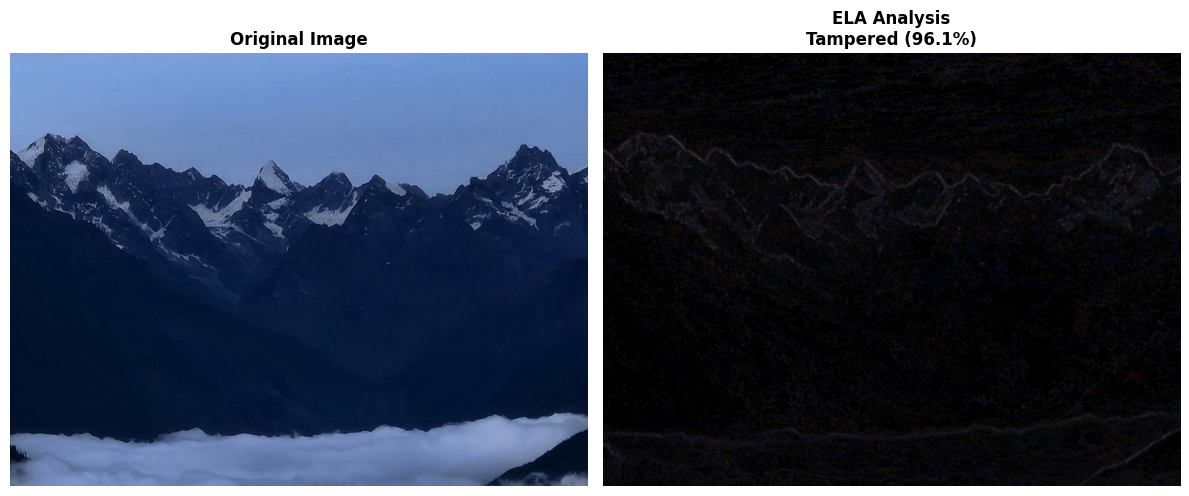


[2/3] Extracting Metadata...
  ✗ No EXIF metadata found

[3/3] Weather Validation...
  ⚠ Skipped - No metadata available

FINAL ANALYSIS RESULTS

TAMPERING CONFIDENCE SCORE:    57.66%
INTERPRETATION:                🟡 UNCERTAIN - FURTHER INSPECTION RECOMMENDED

------------------------------------------------------------
DETAILED ANALYSIS:
------------------------------------------------------------
1. ELA Analysis: Image classified as 'Tampered' with 96.10% confidence
2. No EXIF metadata available for validation


In [44]:
# ========================================
# UPLOAD YOUR IMAGE HERE
# ========================================
# Method 1: Specify the path to your image
IMAGE_PATH = '/home/alookaladdoo/Pictures/phulara.jpg'

# Example paths (uncomment one to use):
# IMAGE_PATH = 'test_image.jpg'
# IMAGE_PATH = 'Image-Tampering-Detection-using-ELA-and-Metadata-Analysis/imgs/sample.jpg'

# Check if file exists
if os.path.exists(IMAGE_PATH):
    print(f"✓ Image found: {IMAGE_PATH}")
    print(f"  File size: {os.path.getsize(IMAGE_PATH) / 1024:.2f} KB\n")
    
    # Run detection
    results = detect_image_tampering(IMAGE_PATH, show_visualizations=True)
    
    # Display results
    display_tampering_results(results)
else:
    print(f"✗ Error: Image not found at '{IMAGE_PATH}'")
    print("\nPlease update the IMAGE_PATH variable with the correct path to your image.")
    print("\nAlternatively, use Option 2 below to upload using a file widget.")

---

## How to Use This Notebook

### Quick Start:
1. **Run all cells up to Section 6** (Cells 1-5) to load models and define functions
2. **In Section 6**, edit the `IMAGE_PATH` variable and run the cell
3. **View results** including ELA visualization and tampering score

### Understanding the Score:
- **0-30%**: Image is likely authentic
- **30-60%**: Uncertain, further inspection recommended
- **60-100%**: Image is likely tampered

### What's Being Analyzed:
1. **ELA (Error Level Analysis)** - 60% weight
   - Analyzes compression artifacts
   - Highlights regions with different compression levels
   
2. **Weather Validation** - 40% weight (if metadata available)
   - Compares detected weather with historical data
   - Uses EXIF GPS and timestamp metadata

### Troubleshooting:
- If models fail to load, check the paths in Section 3
- If metadata is not found, the image may not have EXIF data

---